In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### tp5_tp6. Filtrar, agrupar datos. Unir y separar datos de una columna. Pivotear tablas. Longer pivot. Wider pivot.
# Crear variables dummies.
# Gráficos de línea, barra, dispersión, boxplot usando Python.

In [3]:
tabla5=pd.read_csv(r'C:\Users\Usuario\Documents\Python Scripts\pop_housing_censuses.csv' )
t5=pd.DataFrame(tabla5)
t5

,iddate,year,idgeo,isoalpha3,source,indicator,area,quintile,sex,education_level,age,ethnicity,value,se,cv,sample
0,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_24,Total,0.302885,0.178212,0.588380,66484.0
1,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_29,Total,0.312607,0.153185,0.490024,91575.0
2,year,1970,country,ARG,IPUMS,jefa_ch_PHC,Total,Total,Total,Total,Total,Total,0.165427,0.106774,0.645448,121099.0
3,year,1970,country,ARG,IPUMS,pobfem_ci_PHC,Total,Total,Total,Total,Total,Total,0.503334,0.073178,0.145387,466827.0
4,year,1970,country,ARG,IPUMS,miembro6_ch_PHC,Total,Total,Total,Total,Total,Total,0.301808,0.131912,0.437070,121100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279224,year,2001,country,VEN,IPUMS,dismental_ci_PHC,Total,Total,women,Total,Total,Total,0.003230,0.005278,1.634063,1155815.0
279225,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,rural,Total,women,Total,Total,Total,0.042103,0.057838,1.373727,120562.0
279226,year,2001,country,VEN,IPUMS,dismental_ci_PHC,rural,Total,women,Total,Total,Total,0.003766,0.017640,4.684407,120562.0
279227,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,urban,Total,women,Total,Total,Total,0.037571,0.018689,0.497437,1035253.0


In [4]:
# Analisis exploratio
#++++++++++++++++++++
t5.dtypes
# se: Standard error, cv: coefficent of variation mu/x

iddate              object
year                 int64
idgeo               object
isoalpha3           object
source              object
indicator           object
area                object
quintile            object
sex                 object
education_level     object
age                 object
ethnicity           object
value              float64
se                 float64
cv                 float64
sample             float64
dtype: object

In [5]:
# indicadores estadisticos
t5[["year","sample"]].describe()

,year,sample
count,279229.000000,2.790990e+05
mean,1994.185815,3.191302e+05
std,15.309689,1.089746e+06
min,1960.000000,1.000000e+00
25%,1982.000000,5.532000e+03
50%,2000.000000,2.906000e+04
75%,2005.000000,1.384680e+05
max,2015.000000,2.478972e+07


In [6]:
# Cantidad de valores ausentes por atributo
t5.isna().sum().sort_values()

iddate               0
year                 0
idgeo                0
isoalpha3            0
source               0
indicator            0
area                 0
quintile             0
sex                  0
education_level      0
age                  0
ethnicity            0
value                0
sample             130
se                 447
cv                 577
dtype: int64

In [7]:
# tabla de frecuencia de una variable categórica
# Contar la cantidad de encuestados por nuvel educativo y por sexo.
tf=t5[['education_level','sex']].value_counts()
tf

education_level  sex  
Total            Total    97184
                 men      87213
                 women    83797
primary          Total     1626
                 women     1626
                 men       1625
secondary        Total     1233
                 men       1233
                 women     1232
tertiary         Total      822
                 women      820
                 men        818
Name: count, dtype: int64

In [8]:
t6=t5[["year","isoalpha3","source","area","sex","education_level","age","ethnicity","sample"]]
t6

,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0
...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0


In [9]:
t6.shape

(279229, 9)

In [10]:
t6.dtypes

year                 int64
isoalpha3           object
source              object
area                object
sex                 object
education_level     object
age                 object
ethnicity           object
sample             float64
dtype: object

In [11]:
# Filtrar datos 1 # : Condición OR (Disyunción) se usa cuando AL MENOS una de las condiciones es verdadera.
#++++++++++++++++++
# Hallar la cantidad de personas encuestadas en: Argentina, Brasil 0 México  por: area y nivel educativo 
filtered_df = t5[(t5['isoalpha3'] == 'MEX') | (t5['isoalpha3'] == 'ARG') | (t5['isoalpha3']=="BRA")]
filtered_df2=filtered_df[['isoalpha3','area','sex','education_level','ethnicity','sample']]
filtered_df2

,isoalpha3,area,sex,education_level,ethnicity,sample
0,ARG,rural,Total,Total,Total,66484.0
1,ARG,rural,Total,Total,Total,91575.0
2,ARG,Total,Total,Total,Total,121099.0
3,ARG,Total,Total,Total,Total,466827.0
4,ARG,Total,Total,Total,Total,121100.0
...,...,...,...,...,...,...
201495,MEX,urban,women,Total,Indi,822638.0
201496,MEX,urban,women,Total,Indi,2547.0
201497,MEX,urban,women,Total,Otro,2322592.0
201498,MEX,urban,women,Total,Otro,2322592.0


In [12]:
#Ver todas las categorías únicas en la columna 'isoalpha3'
categorias_isoalpha2 = filtered_df2['isoalpha3'].unique()
print(categorias_isoalpha2)

['ARG' 'BRA' 'MEX']


In [13]:
# Filtrar datos 2 #:  Condición AND (Conjuncion) se usa cuando TODAS las condiciones son verdaderas
#++++++++++++++++
# Hallar la cantidad de personas encuestadas en:  México, que vivan en la zona urbana y que sean de sexo femenino. 

filtered_df3 = t5[(t5['isoalpha3'] == 'MEX') & (t5['area'] == 'urban') & (t5['sex']=="women")]
filtered_df4=filtered_df3[['isoalpha3','area','sex','education_level','ethnicity','sample']]
filtered_df4

,isoalpha3,area,sex,education_level,ethnicity,sample
166029,MEX,urban,women,Total,Total,10511.0
167124,MEX,urban,women,Total,Total,10511.0
167261,MEX,urban,women,Total,Total,16.0
167444,MEX,urban,women,Total,Total,16.0
167535,MEX,urban,women,Total,Total,345.0
...,...,...,...,...,...,...
201495,MEX,urban,women,Total,Indi,822638.0
201496,MEX,urban,women,Total,Indi,2547.0
201497,MEX,urban,women,Total,Otro,2322592.0
201498,MEX,urban,women,Total,Otro,2322592.0


In [14]:
#Ver todas las categorías únicas en la columna 'isoalpha3'
categorias_isoalpha3 = filtered_df4['isoalpha3'].unique()
print(categorias_isoalpha3)

['MEX']


In [15]:
# Ver todas las categorías únicas en la columna 'education_level'
categorias_isoalpha3 = filtered_df4['education_level'].unique()
print(categorias_isoalpha3)

['Total' 'primary' 'secondary' 'tertiary']


In [16]:
# Filtrar datos 3 #:  Condición NOT (Negación) se usa para negar la búsqueda de una categoría.
#++++++++++++++++
# Filtrar los países que no sean  Brasil ni Argentina
filtered_df5 = t5[(t5['isoalpha3'] != 'BRA') & (t5['isoalpha3']!='ARG')]
filtered_df5

,iddate,year,idgeo,isoalpha3,source,indicator,area,quintile,sex,education_level,age,ethnicity,value,se,cv,sample
1333,year,1976,country,BOL,IPUMS,tasa_agro_PHC,Total,Total,men,Total,15_24,Total,0.474637,0.292447,0.616148,29157.0
2647,year,1992,country,BOL,IPUMS,tasa_asis_edad_PHC,Total,Total,men,Total,12_14,Total,1.000000,0.000000,0.000000,20316.0
2694,year,1992,country,BOL,IPUMS,tasa_asis_edad_PHC,Total,Total,men,Total,15_17,Total,1.000000,0.000000,0.000000,12907.0
2921,year,1992,country,BOL,IPUMS,tasa_asis_edad_PHC,Total,Total,men,Total,18_23,Total,1.000000,0.000000,0.000000,10604.0
3327,year,1992,country,BOL,IPUMS,tasa_agro_PHC,urban,Total,Total,Total,65+,Total,0.244460,0.656457,2.685337,4287.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279224,year,2001,country,VEN,IPUMS,dismental_ci_PHC,Total,Total,women,Total,Total,Total,0.003230,0.005278,1.634063,1155815.0
279225,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,rural,Total,women,Total,Total,Total,0.042103,0.057838,1.373727,120562.0
279226,year,2001,country,VEN,IPUMS,dismental_ci_PHC,rural,Total,women,Total,Total,Total,0.003766,0.017640,4.684407,120562.0
279227,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,urban,Total,women,Total,Total,Total,0.037571,0.018689,0.497437,1035253.0


In [17]:
filtered_df5[f'isoalpha3'].unique()

array(['BOL', 'CHL', 'COL', 'CRI', 'DOM', 'ECU', 'GTM', 'HND', 'HTI',
       'JAM', 'MEX', 'NIC', 'PAN', 'PER', 'PRY', 'SLV', 'SUR', 'TTO',
       'URY', 'VEN'], dtype=object)

In [ ]:
# Agrupar datos #: (agrupar y sumar datos)
#++++++++++++++++

# reset_index(): actualiza el indice de la nueva tabla de datos filtrados o agrupados.
f2b=filtered_df2[filtered_df2['education_level']!='Total']
f2b

,isoalpha3,area,sex,education_level,ethnicity,sample
38,ARG,Total,Total,primary,Total,466860.0
39,ARG,Total,Total,primary,Total,466860.0
40,ARG,Total,Total,secondary,Total,466860.0
41,ARG,Total,Total,secondary,Total,466860.0
42,ARG,Total,Total,tertiary,Total,466860.0
...,...,...,...,...,...,...
195865,MEX,urban,women,tertiary,Otro,2328290.0
195866,MEX,urban,women,tertiary,Otro,2328290.0
195880,MEX,urban,women,primary,Otro,2328290.0
195881,MEX,urban,women,secondary,Otro,2328290.0


In [42]:
numeric_cols=f2b.select_dtypes(include='number').columns
grouped_df2=f2b.groupby(['isoalpha3', 'area', 'education_level'])[numeric_cols].sum().reset_index()
grouped_df2

,isoalpha3,area,education_level,sample
0,ARG,Total,primary,77844095.0
1,ARG,Total,secondary,74071983.0
2,ARG,Total,tertiary,49381322.0
3,ARG,rural,primary,5076018.0
4,ARG,rural,secondary,4781244.0
5,ARG,rural,tertiary,3187496.0
6,ARG,urban,primary,44782628.0
7,ARG,urban,secondary,42470172.0
8,ARG,urban,tertiary,28313448.0
9,BRA,Total,primary,895695028.0


In [43]:
print(f2b.dtypes)

isoalpha3           object
area                object
sex                 object
education_level     object
ethnicity           object
sample             float64
dtype: object


In [48]:
# Agrupar datos #: (agrupar y calcular el promedio)
#++++++++++++++++
numeric_cols = f2b.select_dtypes(include='number').columns
grouped_df3= f2b.groupby(['isoalpha3', 'area', 'education_level'])[numeric_cols].mean().reset_index()

grouped_df3


,isoalpha3,area,education_level,sample
0,ARG,Total,primary,1.621752e+06
1,ARG,Total,secondary,2.057555e+06
2,ARG,Total,tertiary,2.057555e+06
3,ARG,rural,primary,2.115008e+05
4,ARG,rural,secondary,2.656247e+05
5,ARG,rural,tertiary,2.656247e+05
6,ARG,urban,primary,1.865943e+06
7,ARG,urban,secondary,2.359454e+06
8,ARG,urban,tertiary,2.359454e+06
9,BRA,Total,primary,5.428455e+06


In [49]:
# Agrupar por 'education_level' y sumar 'value' y 'sample'
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++

suma_valores = t5.groupby('education_level')[['value', 'sample']].sum()
print(suma_valores)

                        value        sample
education_level                            
Total            2.396383e+11  7.919691e+10
primary          2.570983e+05  3.736777e+09
secondary        1.079389e+05  3.563218e+09
tertiary         4.910983e+04  2.572010e+09


In [50]:
grouped_df2.dtypes



isoalpha3           object
area                object
education_level     object
sample             float64
dtype: object

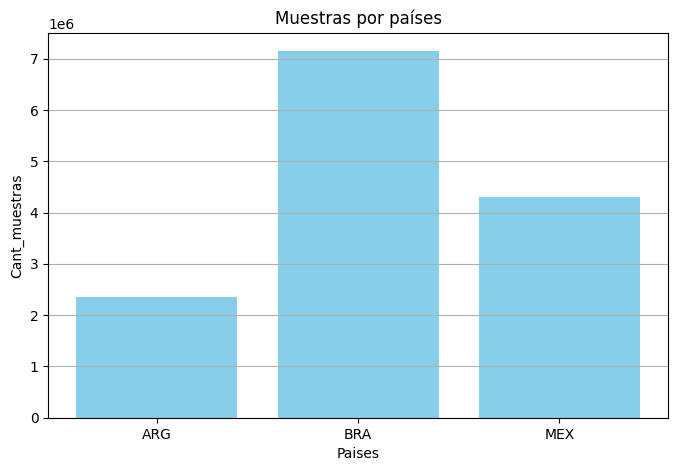

In [52]:
import matplotlib.pyplot as plt

# Definir las variables
pais=grouped_df2['isoalpha3']
Cant_muestras=grouped_df2['sample']

# Crear el gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(pais, Cant_muestras, color="skyblue")

# Personalizar el gráfico
plt.xlabel("Paises")
plt.ylabel("Cant_muestras")
plt.title("Muestras por países")
plt.grid(axis="y")

# Mostrar el gráfico
plt.show()


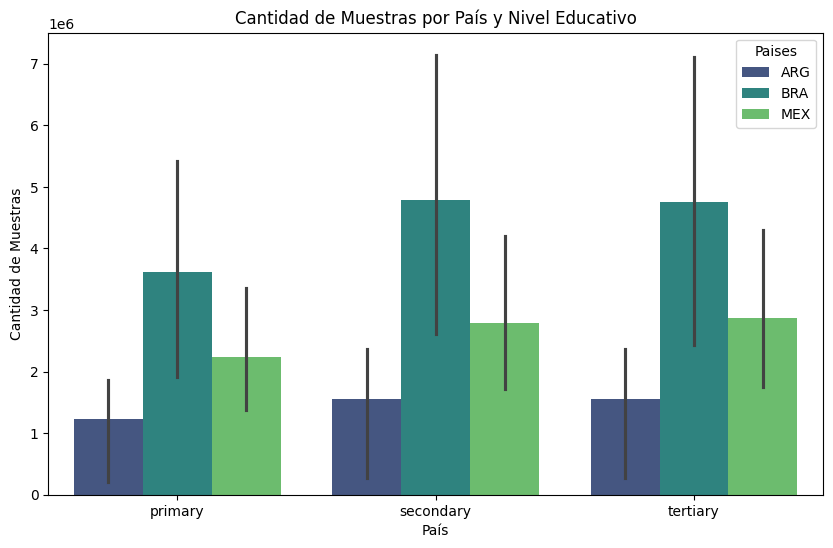

In [63]:
import seaborn as sns

# Crear DataFrame para graficar
df_plot = grouped_df2.reset_index()

# Gráfico con múltiples categorías
plt.figure(figsize=(10,6))
sns.barplot(data=df_plot, x="education_level",y="sample",hue="isoalpha3", palette="viridis")

# Personalización
plt.xlabel("País")
plt.ylabel("Cantidad de Muestras")
plt.title("Cantidad de Muestras por País y Nivel Educativo")
#plt.xticks(rotation=45)
plt.legend(title="Paises")

# Mostrar gráfico
plt.show()



In [64]:
# Unir Columnas
#++++++++++++++
#  Crear una columna llamada "Country_Area" que muestre el "Pais/"Area"

# Unir datos de dos o mas columnas
# La función assign asigna una nueva columa a un dataframe.

t7=t6.assign(Country_Area=t6['isoalpha3']+"/"+t6['area'])
t7

,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample,Country_Area
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0,ARG/rural
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0,ARG/rural
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0,ARG/Total
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0,ARG/Total
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0,ARG/Total
...,...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0,VEN/Total
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN/rural
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN/rural
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0,VEN/urban


In [65]:
# Separar datos de una columna
#+++++++++++++++++++++++++++++
# Separar los datos de la Columna "Country_Area" creando una var. llamada "Pais" y otra llamada "Zona"

new_columns=(t7.Country_Area.str.split("/",expand=True).
      rename(columns={0:"Pais",1:"Zona"}))

new_columns

,Pais,Zona
0,ARG,rural
1,ARG,rural
2,ARG,Total
3,ARG,Total
4,ARG,Total
...,...,...
279224,VEN,Total
279225,VEN,rural
279226,VEN,rural
279227,VEN,urban


In [66]:

# Agregamos la nuevas columnas al Data set y eliminamos la columna con datos fusionados
# la función concat se utiliza para unir data frames.

t8=pd.concat([t7.drop(columns='Country_Area'),new_columns],axis=1)
t8


,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample,Pais,Zona
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0,ARG,rural
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0,ARG,rural
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0,ARG,Total
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0,ARG,Total
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0,ARG,Total
...,...,...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0,VEN,Total
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN,rural
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN,rural
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0,VEN,urban


In [67]:
# Pivot table: intercambiar filas por columnas
#+++++++++++++++++++++++++++++++++++++++++++++
# wider pivot: los valores de las filas se transforman en columnas. Se expande en direccion a las columnas.
# longer pivot: los valores de las columnas se transforman en filas. Se expande en direccion a las  filas.

#  Wider Pivot:
# +++++++++++++
#  mostrar el valor de las muestras por pais y por area de recoleccion de dato

t9=t5.pivot_table(index=['isoalpha3'], # filtra por pais
               columns='area', # muestra la columna a pivotear formada por las categorias: total, rural, urban
               values='sample', # valor a asignar en la tabla pivoteada.
               fill_value='sin datos') # reemplaza missing value con "0"
t9

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7628\3648701096.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t9=t5.pivot_table(index=['isoalpha3'], # filtra por pais


area,Total,rural,urban
isoalpha3,,,
ARG,5.719996e+05,70460.473004,630703.312453
BOL,1.043494e+05,40025.497307,64143.203509
BRA,2.135648e+06,653180.264576,1469110.580306
CHL,1.892363e+05,30526.425698,154820.618325
COL,4.872746e+05,162826.755621,313383.197508
CRI,3.993962e+04,14926.568586,25138.264871
DOM,1.027212e+05,37508.166856,69598.421875
ECU,1.333772e+05,42828.112903,89143.861676
GTM,7.729417e+04,43957.638795,32459.945755


In [68]:
#  Wider Pivot: mostrar el valor de las muestras por pais y por año en relación al area de recoleccion de datos
t10=t5.pivot_table(index=['isoalpha3','year'], # filtra por año y por pais
               columns='area', # muestra la columna a pivotear formada por las categorias: total, rural, urban
               values='sample', # valor a asignar en la tabla pivoteada.
               fill_value='sin datos') # reemplaza missing value con "0"
t10

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7628\1714096515.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t10=t5.pivot_table(index=['isoalpha3','year'], # filtra por año y por pais


area                   Total          rural          urban
isoalpha3 year                                            
ARG       1970  8.996157e+04      sin datos      sin datos
          1991  8.080021e+05   77277.743902  705102.727273
          2001  6.360442e+05   63674.236722  556863.291729
          2010  1.613291e+06      sin datos      sin datos
BOL       1976  8.229897e+04   47863.862069   33426.531298
...                      ...            ...            ...
URY       2011  6.143236e+04      sin datos      sin datos
VEN       1971  2.532082e+05      sin datos      sin datos
          1981  2.499586e+05   35957.098462  208065.656061
          1990  3.050524e+05  112808.091047  185461.019549
          2001  4.240042e+05   46002.103187  368420.494737

[96 rows x 3 columns]

In [69]:
#  Longer Pivot. (UNPIVOT)
#+++++++++++++++++++++++++
# Comprime un conjunto de variables en una unica columna.

t11=t10.melt(var_name='area',value_name='sample') # var_name: muestra la var. cat. a comprimir, value_name: el valor num. asignado.
t11

,area,sample
0,Total,89961.570992
1,Total,808002.085586
2,Total,636044.222057
3,Total,1613290.810811
4,Total,82298.969743
...,...,...
283,urban,sin datos
284,urban,sin datos
285,urban,208065.656061
286,urban,185461.019549


In [85]:
# Variables dummies (transformar var-categoricas en numericas)
#++++++++++++++++++
# Las variables dummy son columnas binarias (0 o 1) que indican la presencia o ausencia de cada categoría en la columna original.
# Es una forma de cuantificar datos cualitativos.

t12 = pd.get_dummies(t5['area']).astype(int)

print(t12)

        Total  rural  urban
0           0      1      0
1           0      1      0
2           1      0      0
3           1      0      0
4           1      0      0
...       ...    ...    ...
279224      1      0      0
279225      0      1      0
279226      0      1      0
279227      0      0      1
279228      0      0      1

[279229 rows x 3 columns]


In [86]:
# Cambiar el indice de una var. dummies indicando el pais de cada registro
# set_index: Establece una columna como índice de un data frame.

t12.set_index(t5['isoalpha3'] ,inplace=True)
t12

,Total,rural,urban
isoalpha3,,,
ARG,0,1,0
ARG,0,1,0
ARG,1,0,0
ARG,1,0,0
ARG,1,0,0
...,...,...,...
VEN,1,0,0
VEN,0,1,0
VEN,0,1,0


In [87]:
# Renombramos las columnas: Total, rural y urban por : Bar_tot, Zona_campo, Zona_urbana
t12.rename(columns={'Total':'Var_tot','rural': 'Zona_campo', 'urban':'Zona_urbana'},inplace=True)

# Renombramos el titulo del indice "isoalpha3" por "Pais_Latam"
t12.rename_axis('Pais_Latam', inplace=True)
t12

,Var_tot,Zona_campo,Zona_urbana
Pais_Latam,,,
ARG,0,1,0
ARG,0,1,0
ARG,1,0,0
ARG,1,0,0
ARG,1,0,0
...,...,...,...
VEN,1,0,0
VEN,0,1,0
VEN,0,1,0
